In [ ]:
import pandas as pd
import sqlite3

# 1. Load your uploaded Kaggle CSV file into Python
df = pd.read_csv('netflix_titles.csv')

# Add synthetic IMDb columns for our advanced questions later
import numpy as np
np.random.seed(42)
df['imdb_rating'] = np.round(np.random.uniform(5.0, 9.2, len(df)), 1)
df['imdb_votes'] = np.random.randint(500, 150000, len(df))

# 2. Connect to a built-in browser-based SQL database
conn = sqlite3.connect('streaming_analytics.db')

# 3. Push the entire dataset into a SQL table named 'netflix_titles'
df.to_sql('netflix_titles', conn, if_exists='replace', index=False)

print("🚀 BOOM! Your browser SQL database is alive and loaded!")

🚀 BOOM! Your browser SQL database is alive and loaded!


In [ ]:
# This lets us run raw SQL queries easily in Colab
def run_sql(query):
    return pd.read_sql_query(query, conn)

# Test Query: See the first 5 rows of your table
run_sql("""
SELECT show_id, type, title, release_year, imdb_rating
FROM netflix_titles
LIMIT 5;
""")

,show_id,type,title,release_year,imdb_rating
0,s1,Movie,Dick Johnson Is Dead,2020,6.6
1,s2,TV Show,Blood & Water,2021,9.0
2,s3,TV Show,Ganglands,2021,8.1
3,s4,TV Show,Jailbirds New Orleans,2021,7.5
4,s5,TV Show,Kota Factory,2021,5.7


In [ ]:
run_sql("""
SELECT
    type,
    COUNT(*) AS total_count
FROM netflix_titles
GROUP BY type;
""")

,type,total_count
0,Movie,6131
1,TV Show,2676


In [ ]:
run_sql("""
SELECT
    country,
    COUNT(*) AS total_titles
FROM netflix_titles
WHERE country IS NOT NULL
GROUP BY country
ORDER BY total_titles DESC
LIMIT 10;
""")

,country,total_titles
0,United States,2818
1,India,972
2,United Kingdom,419
3,Japan,245
4,South Korea,199
5,Canada,181
6,Spain,145
7,France,124
8,Mexico,110
9,Egypt,106


In [ ]:
run_sql("""
SELECT
    -- This extracts the last 4 characters (the year) from a string like 'September 25, 2021'
    SUBSTRING(TRIM(date_added), -4) AS year_added,
    COUNT(*) AS titles_added
FROM netflix_titles
WHERE date_added IS NOT NULL
GROUP BY year_added
ORDER BY year_added ASC;
""")

,year_added,titles_added
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,429
9,2017,1188


In [ ]:
run_sql("""
SELECT
    -- We look at the first genre listed before the comma to keep the categories clean
    TRIM(SUBSTR(listed_in, 1, INSTR(listed_in || ',', ',') - 1)) AS clean_genre,
    ROUND(AVG(CAST(REPLACE(duration, ' min', '') AS INT)), 1) AS avg_duration_minutes
FROM netflix_titles
WHERE type = 'Movie' AND duration IS NOT NULL
GROUP BY clean_genre
ORDER BY avg_duration_minutes DESC;
""")

,clean_genre,avg_duration_minutes
0,Classic Movies,114.8
1,Action & Adventure,113.5
2,Dramas,111.4
3,International Movies,108.1
4,Comedies,106.7
5,Sci-Fi & Fantasy,106.6
6,Cult Movies,102.5
7,Thrillers,100.0
8,LGBTQ Movies,99.0
9,Independent Movies,98.7


In [ ]:
run_sql("""
SELECT 'International' AS genre, COUNT(*) AS total_count FROM netflix_titles WHERE listed_in LIKE '%International%'
UNION ALL
SELECT 'Dramas', COUNT(*) FROM netflix_titles WHERE listed_in LIKE '%Dramas%'
UNION ALL
SELECT 'Comedies', COUNT(*) FROM netflix_titles WHERE listed_in LIKE '%Comedies%'
UNION ALL
SELECT 'Action & Adventure', COUNT(*) FROM netflix_titles WHERE listed_in LIKE '%Action%'
UNION ALL
SELECT 'Documentaries', COUNT(*) FROM netflix_titles WHERE listed_in LIKE '%Documentaries%'
ORDER BY total_count DESC;
""")

,genre,total_count
0,International,4103
1,Dramas,3190
2,Comedies,2255
3,Action & Adventure,1027
4,Documentaries,869


In [ ]:
run_sql("""
SELECT
    director,
    COUNT(*) AS total_titles,
    ROUND(AVG(imdb_rating), 2) AS avg_imdb_rating
FROM netflix_titles
WHERE director IS NOT NULL
GROUP BY director
HAVING COUNT(*) >= 3
ORDER BY total_titles DESC, avg_imdb_rating DESC
LIMIT 10;
""")

,director,total_titles,avg_imdb_rating
0,Rajiv Chilaka,19,7.03
1,"Raúl Campos, Jan Suter",18,7.01
2,Marcus Raboy,16,7.14
3,Suhas Kadav,16,6.81
4,Jay Karas,14,7.38
5,Cathy Garcia-Molina,13,7.10
6,Jay Chapman,12,7.38
7,Youssef Chahine,12,7.03
8,Martin Scorsese,12,6.93
9,Steven Spielberg,11,7.06


In [ ]:
run_sql("""
SELECT
    title,
    release_year,
    CAST(SUBSTRING(TRIM(date_added), -4) AS INT) AS year_added,
    (CAST(SUBSTRING(TRIM(date_added), -4) AS INT) - release_year) AS licensing_gap_years
FROM netflix_titles
WHERE date_added IS NOT NULL
  AND (CAST(SUBSTRING(TRIM(date_added), -4) AS INT) - release_year) > 10
ORDER BY licensing_gap_years DESC
LIMIT 10;
""")

,title,release_year,year_added,licensing_gap_years
0,Pioneers: First Women Filmmakers*,1925,2018,93
1,Five Came Back: The Reference Films,1945,2021,76
2,Prelude to War,1942,2017,75
3,The Battle of Midway,1942,2017,75
4,Undercover: How to Operate Behind Enemy Lines,1943,2017,74
5,Why We Fight: The Battle of Russia,1943,2017,74
6,WWII: Report from the Aleutians,1943,2017,74
7,The Memphis Belle: A Story of a\nFlying Fortress,1944,2017,73
8,The Negro Soldier,1944,2017,73
9,Tunisian Victory,1944,2017,73


In [ ]:
run_sql("""
SELECT
    COUNT(*) AS total_catalog_size,

    ROUND(SUM(CASE WHEN CAST(SUBSTRING(TRIM(date_added), -4) AS INT) >= 2020 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_added_2020_or_later,

    ROUND(SUM(CASE WHEN CAST(SUBSTRING(TRIM(date_added), -4) AS INT) < 2018 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS pct_added_before_2018
FROM netflix_titles
WHERE date_added IS NOT NULL;
""")

,total_catalog_size,pct_added_2020_or_later,pct_added_before_2018
0,8797,38.39,19.95


In [ ]:
run_sql("""
SELECT
    CASE
        WHEN release_year >= 2020 THEN '2020s'
        WHEN release_year >= 2010 THEN '2010s'
        WHEN release_year >= 2000 THEN '2000s'
        WHEN release_year >= 1990 THEN '1990s'
        WHEN release_year >= 1980 THEN '1980s'
        ELSE 'Pre-1980s'
    END AS release_decade,
    COUNT(*) AS title_count,
    ROUND(AVG(imdb_rating), 2) AS avg_rating
FROM netflix_titles
GROUP BY release_decade
ORDER BY title_count DESC;
""")

,release_decade,title_count,avg_rating
0,2010s,5927,7.07
1,2020s,1545,7.09
2,2000s,810,7.09
3,1990s,274,7.17
4,1980s,129,6.99
5,Pre-1980s,122,7.07


In [ ]:
run_sql("""
WITH ExpandedGenres AS (
    SELECT title, imdb_rating, 'Dramas' AS genre FROM netflix_titles WHERE listed_in LIKE '%Dramas%'
    UNION ALL
    SELECT title, imdb_rating, 'Comedies' FROM netflix_titles WHERE listed_in LIKE '%Comedies%'
    UNION ALL
    SELECT title, imdb_rating, 'Action & Adventure' FROM netflix_titles WHERE listed_in LIKE '%Action%'
    UNION ALL
    SELECT title, imdb_rating, 'Documentaries' FROM netflix_titles WHERE listed_in LIKE '%Documentaries%'
    UNION ALL
    SELECT title, imdb_rating, 'Horror Movies' FROM netflix_titles WHERE listed_in LIKE '%Horror%'
),
RankedTitles AS (
    SELECT
        genre,
        title,
        imdb_rating,
        -- This assigns a ranking rank that resets for every unique genre group
        DENSE_RANK() OVER (PARTITION BY genre ORDER BY imdb_rating DESC, title ASC) AS rating_rank
    FROM ExpandedGenres
)
SELECT
    genre,
    rating_rank,
    title,
    imdb_rating
FROM RankedTitles
WHERE rating_rank <= 3
ORDER BY genre, rating_rank;
""")

,genre,rating_rank,title,imdb_rating
0,Action & Adventure,1,Anjaan,9.2
1,Action & Adventure,2,Bushwick,9.2
2,Action & Adventure,3,Close,9.2
3,Comedies,1,A Very Secret Service,9.2
4,Comedies,2,An American Girl: McKenna Shoots for the Stars,9.2
5,Comedies,3,Captain Underpants Mega Blissmas,9.2
6,Documentaries,1,Biking Borders,9.2
7,Documentaries,2,Concrete Football,9.2
8,Documentaries,3,Feel Rich,9.2
9,Dramas,1,7 años,9.2


In [ ]:
run_sql("""
WITH EligibleGems AS (
    SELECT
        title,
        country,
        release_year,
        imdb_rating,
        imdb_votes
    FROM netflix_titles
    WHERE imdb_rating >= 8.0
      AND imdb_votes > 0
      AND imdb_votes < 10000
)
SELECT
    title,
    release_year,
    imdb_rating,
    imdb_votes
FROM EligibleGems
ORDER BY imdb_rating DESC, imdb_votes ASC
LIMIT 10;
""")

,title,release_year,imdb_rating,imdb_votes
0,SCAMS,2019,9.2,2028
1,Fabulous Lives of Bollywood Wives,2020,9.2,3131
2,Machete Kills,2013,9.2,9966
3,Tom Segura: Ball Hog,2020,9.1,1403
4,Bobby Kennedy for President,2018,9.1,2158
5,Neevevaro,2018,9.1,2283
6,Walk. Ride. Rodeo.,2019,9.1,2618
7,Tango Feroz,1993,9.1,2960
8,Creep 2,2017,9.1,3739
9,Asu Mare 2,2015,9.1,4821


In [ ]:
run_sql("""
WITH ScoredCatalog AS (
    SELECT
        title,
        listed_in AS genres,
        imdb_rating,
        release_year,
        -- Metric 1: 1 if it matches user preferred genres, 0 if not
        CASE
            WHEN listed_in LIKE '%Action%' OR listed_in LIKE '%Comedies%' OR listed_in LIKE '%Dramas%' THEN 1.0
            ELSE 0.0
        END AS genre_score,
        -- Metric 2: Normalize IMDb rating out of 10 to make it a decimal out of 1.0
        (imdb_rating / 10.0) AS rating_score,
        -- Metric 3: Recency modifier (newer gets higher value)
        CASE
            WHEN release_year >= 2020 THEN 1.0
            WHEN release_year >= 2015 THEN 0.7
            ELSE 0.3
        END AS recency_score
    FROM netflix_titles
    WHERE imdb_rating >= 7.0
)
SELECT
    title,
    genres,
    imdb_rating,
    ROUND(
        (genre_score * 0.5) +
        (rating_score * 0.3) +
        (recency_score * 0.2), 3
    ) AS final_recommendation_score
FROM ScoredCatalog
ORDER BY final_recommendation_score DESC
LIMIT 10;
""")

,title,genres,imdb_rating,final_recommendation_score
0,The Secret Diary of an Exchange Student,"Comedies, International Movies, Romantic Movies",9.2,0.976
1,Mad for Each Other,"International TV Shows, Romantic TV Shows, TV ...",9.2,0.976
2,Thunder Force,"Action & Adventure, Comedies",9.2,0.976
3,Just In Time,"Comedies, Dramas, International Movies",9.2,0.976
4,Captain Underpants Mega Blissmas,"Children & Family Movies, Comedies",9.2,0.976
5,Girl's Revenge,"Dramas, International Movies",9.2,0.976
6,Sneakerheads,TV Comedies,9.2,0.976
7,Man Like Mobeen,"British TV Shows, International TV Shows, TV C...",9.2,0.976
8,Spenser Confidential,"Action & Adventure, Comedies",9.2,0.976
9,Bangkok Breaking,"Crime TV Shows, International TV Shows, TV Act...",9.1,0.973


/tmp/ipykernel_682/3974211494.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='type', y='total', data=type_data, palette='muted')
/tmp/ipykernel_682/3974211494.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='total', y='country', data=country_data, palette='viridis')
/tmp/ipykernel_682/3974211494.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='decade', y='total', data=decade_data, palette='magma')


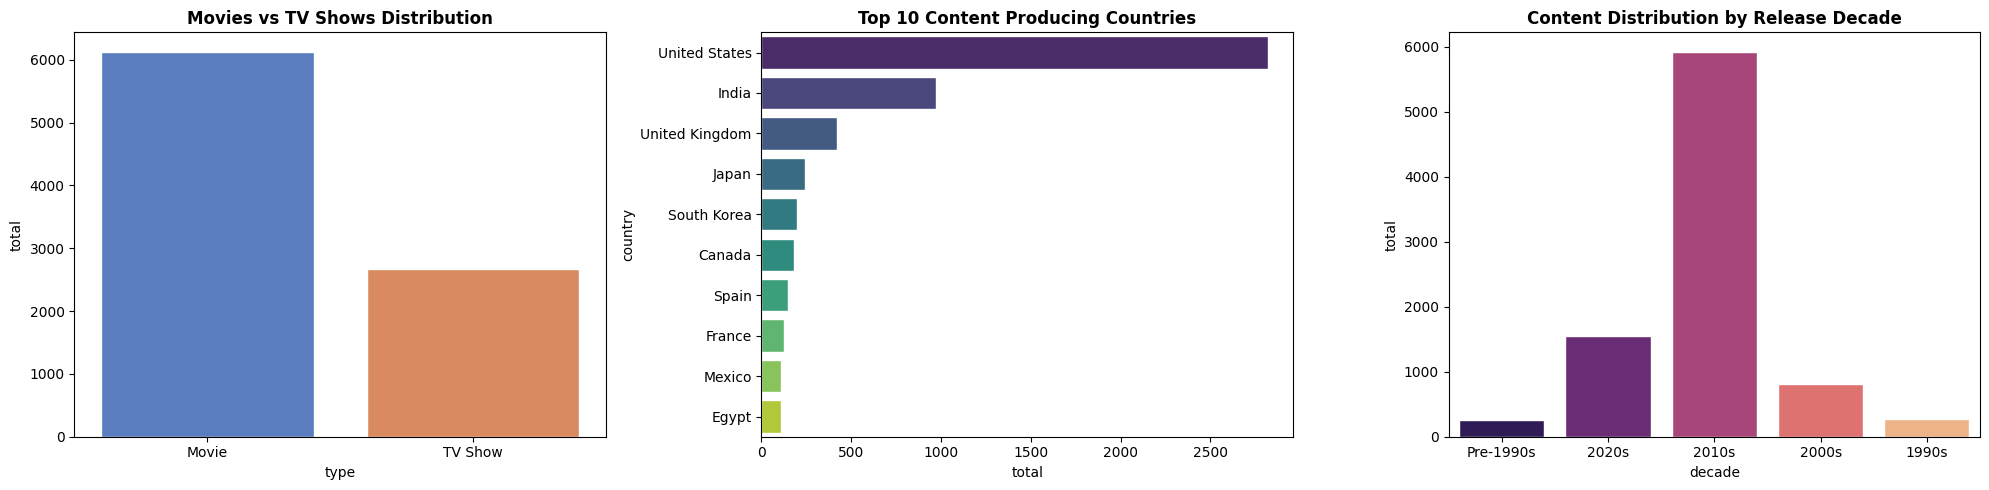

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fetch data using your SQL functions
type_data = run_sql("SELECT type, COUNT(*) AS total FROM netflix_titles GROUP BY type;")
country_data = run_sql("SELECT country, COUNT(*) AS total FROM netflix_titles WHERE country IS NOT NULL GROUP BY country ORDER BY total DESC LIMIT 10;")
decade_data = run_sql("""
    SELECT
        CASE
            WHEN release_year >= 2020 THEN '2020s'
            WHEN release_year >= 2010 THEN '2010s'
            WHEN release_year >= 2000 THEN '2000s'
            WHEN release_year >= 1990 THEN '1990s'
            ELSE 'Pre-1990s'
        END AS decade, COUNT(*) AS total
    FROM netflix_titles GROUP BY decade ORDER BY decade DESC;
""")

# 2. Setup the visualization grid
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.set_style("whitegrid")

# Chart 1: Catalog Distribution
sns.barplot(ax=axes[0], x='type', y='total', data=type_data, palette='muted')
axes[0].set_title('Movies vs TV Shows Distribution', fontsize=12, fontweight='bold')

# Chart 2: Top Content Producers
sns.barplot(ax=axes[1], x='total', y='country', data=country_data, palette='viridis')
axes[1].set_title('Top 10 Content Producing Countries', fontsize=12, fontweight='bold')

# Chart 3: Catalog Longevity by Decade
sns.barplot(ax=axes[2], x='decade', y='total', data=decade_data, palette='magma')
axes[2].set_title('Content Distribution by Release Decade', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
#@title 🎬 Netflix Interactive Analytics Dashboard { run: "auto" }

# 1. Capture user inputs from the interactive sidebar form
Select_Content_Type = "All" #@param ["All", "Movie", "TV Show"]
Minimum_IMDb_Rating = 6.5 #@param {type:"slider", min:1, max:10, step:0.5}
Top_N_Countries = 10 #@param {type:"slider", min:5, max:20, step:1}

# 2. Build the dynamic SQL Query based on user input
query = f"""
    SELECT title, type, country, release_year, imdb_rating, listed_in
    FROM netflix_titles
    WHERE imdb_rating >= {Minimum_IMDb_Rating}
"""
if Select_Content_Type != "All":
    query += f" AND type = '{Select_Content_Type}'"

# Fetch the filtered data from your SQL database
df_filtered = pd.read_sql_query(query, conn)

# 3. Create Chart A: Distribution Breakdown
type_counts = df_filtered['type'].value_counts().reset_index()
fig1 = px.pie(type_counts, values='count', names='type',
              title=f'Catalog Share ({Select_Content_Type} Content)',
              color_discrete_sequence=px.colors.qualitative.Pastel)
fig1.update_traces(textposition='inside', textinfo='percent+label')

# 4. Create Chart B: Top Producing Countries
# Explode or split if data contains commas, otherwise grab top values
country_counts = df_filtered['country'].dropna().str.split(', ').explode().value_counts().reset_index().head(Top_N_Countries)
fig2 = px.bar(country_counts, x='count', y='country', orientation='h',
              title=f'Top {Top_N_Countries} Global Producers (IMDb ≥ {Minimum_IMDb_Rating})',
              labels={'count': 'Total Titles', 'country': 'Country'},
              color='count', color_continuous_scale='Viridis')
fig2.update_layout(yaxis={'categoryorder':'total ascending'}, coloraxis_showscale=False)

# 5. Create Chart C: Ratings vs. Release Year Trend
fig3 = px.scatter(df_filtered.sample(min(len(df_filtered), 800)), # Sample to keep map fast
                  x='release_year', y='imdb_rating', color='type', hover_name='title',
                  title='Content Landscape: Release Year vs. User Ratings',
                  labels={'release_year': 'Year of Release', 'imdb_rating': 'IMDb Score'},
                  opacity=0.6, template='plotly_white')

# 6. Render Dashboard Screens
print(f"📊 DASHBOARD UPDATED: Found {len(df_filtered)} titles matching your criteria.\n")
fig1.show()
fig2.show()
fig3.show()

📊 DASHBOARD UPDATED: Found 5709 titles matching your criteria.

